# Прогнозирование объёмов добычи нефти и газа на месторождении Volve

Решение кейса: построить математическую модель, которая по истории добычи до заданной даты выдаёт **месячный прогноз нефти и газа на 6 месяцев** по месторождению.

Датасет: производственные данные Volve (Норвегия, 2007–2016), файл `data/data.xlsx`.

Модель проверяется на пяти фиксированных контрольных окнах. Итоговая метрика — **RMS WAPE** отдельно по нефти и по газу.


## 1. Постановка и ограничения

**Что прогнозируем.** Не суточный дебит отдельной скважины, а **месячный профиль месторождения**: сумма добычи нефти и газа по всем стволам.

**Как учимся.** История строго до даты отсечения. Тест всегда позже обучения, без перемешивания во времени.

**Контрольные окна**

| Вариант | Обучение | Прогноз |
|---|---|---|
| 1 | 2007-09-01 — 2009-12-01 | 2010-01 — 2010-06 |
| 2 | 2007-09-01 — 2011-12-01 | 2012-01 — 2012-06 |
| 3 | 2007-09-01 — 2013-12-01 | 2014-01 — 2014-06 |
| 4 | 2007-09-01 — 2014-12-01 | 2015-01 — 2015-06 |
| 5 | 2007-09-01 — 2015-12-01 | 2016-01 — 2016-06 |

**Состав модели**

1. Принимает историю до даты отсечения.
2. Готовит месячный ряд месторождения и лаговые признаки.
3. На хвосте обучения выбирает кандидата: кривая Арпса, сумма скважинных Арпсов, Холт, Ridge с лагами, смесь.
4. Строит рекурсивный прогноз на 6 месяцев и интервал неопределённости.

Код разбит на пакет `src/`: загрузка, признаки, модели, метрики, графики.


In [1]:
%matplotlib inline
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import FIGURES_DIR, GAS_PROFILE_VARIANT, OIL_PROFILE_VARIANT, WINDOWS
from src.data import load_daily, load_monthly, monthly_field, well_summary
from src.evaluate import arps_on_window, evaluate_windows
from src.features import make_supervised
from src.metrics import regression_report
from src.models import FieldForecaster, forecast_arps
from src.plots import (
    plot_compare_arps_ml,
    plot_decomposition,
    plot_errors,
    plot_field_history,
    plot_forecast_vs_actual,
    plot_wells,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
FIGURES_DIR.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("рабочая папка:", ROOT)


рабочая папка: /Users/andreysorokin/Projects/volve-production-forecast


## 2. Загрузка и обзор данных

В Excel три листа:

- `Daily Production Data` — суточные замеры, ~15 600 строк, 7 стволов, 24 колонки;
- `Monthly Production Data` — месячная агрегация, ~527 строк;
- `Описание колонок` — словарь признаков.

Для месячного прогноза по месторождению основной ряд берём с месячного листа и дополнительно сверяем со суточным. Суточные данные нужны для анализа простоев, давлений и типов скважин.


In [2]:
daily = load_daily()
monthly = load_monthly()
field = monthly_field(monthly)

print("суточные строки:", len(daily), "период:", daily["DATEPRD"].min().date(), "—", daily["DATEPRD"].max().date())
print("месячные строки:", len(monthly), "стволов:", monthly["WELL"].nunique())
print("месяцев месторождения:", len(field), field["DATE"].min().date(), "—", field["DATE"].max().date())
display(well_summary(daily, monthly))


суточные строки: 15634 период: 2007-09-01 — 2016-12-01
месячные строки: 526 стволов: 7
месяцев месторождения: 112 2007-09-01 — 2016-12-01


,well,daily_rows,date_min,date_max,flow_kinds,well_types,oil_sm3,gas_sm3,water_sm3,wi_sm3,on_stream_hrs
0,15/9-F-12,3056,2008-02-12,2016-09-17,production,OP,"4,579,609.55","667,542,278.02","6,833,320.37",0.00,"65,204.07"
1,15/9-F-14,3056,2008-02-12,2016-09-17,production,OP,"3,942,233.39","578,009,542.02","7,121,249.74",0.00,"62,773.68"
2,15/9-F-11,1165,2013-07-08,2016-09-17,production,OP,"1,147,849.10","174,310,520.61","1,090,806.27",0.00,"26,006.22"
3,15/9-F-1 C,746,2014-04-07,2016-04-21,production,"OP, WI","177,709.33","26,440,918.60","207,302.39",0.00,"9,983.53"
4,15/9-F-15 D,978,2014-01-12,2016-09-17,production,OP,"148,518.56","22,505,350.95","52,366.40",0.00,"17,824.83"
5,15/9-F-5,3306,2007-09-01,2016-09-18,"injection, production","OP, WI","41,160.68","6,561,825.74","13,533.18","14,089,406.49","60,829.85"
6,15/9-F-4,3327,2007-09-01,2016-12-01,injection,WI,0.00,0.00,0.00,"16,240,727.04","64,267.16"


### Что видно по стволам

- `15/9-F-12` и `15/9-F-14` — основные добывающие скважины с 2008 года.
- `15/9-F-11` подключается в 2013, `F-1 C` и `F-15 D` — в 2014. Это важно: в окне 3 в прогнозный период входят **новые скважины**, которых не было в обучении.
- `15/9-F-4` — нагнетательная, нефти и газа не даёт.
- `15/9-F-5` меняет роль: и закачка, и короткие периоды добычи.

Пропуски в забойных датчиках частые, но целевые объёмы на месячном листе заполнены. Периоды простоя видны по `ON_STREAM_HRS = 0` и нулевой добыче: их не интерполируем как «потерянный дебит», а оставляем нулями — скважина реально не работала.


In [3]:
print("пропуски в суточных целевых колонках, %")
miss = daily[["BORE_OIL_VOL", "BORE_GAS_VOL", "BORE_WAT_VOL", "ON_STREAM_HRS", "AVG_WHP_P", "AVG_DOWNHOLE_PRESSURE"]].isna().mean() * 100
display(miss.to_frame("pct"))

idle = daily.loc[daily["FLOW_KIND"] == "production"]
share_idle = (idle["ON_STREAM_HRS"].fillna(0) <= 0).mean() * 100
print(f"доля суток с нулевым временем работы у добывающих стволов: {share_idle:.1f}%")
display(field.head())


пропуски в суточных целевых колонках, %


,pct
BORE_OIL_VOL,41.40
BORE_GAS_VOL,41.40
BORE_WAT_VOL,41.40
ON_STREAM_HRS,1.82
AVG_WHP_P,41.44
AVG_DOWNHOLE_PRESSURE,42.56


доля суток с нулевым временем работы у добывающих стволов: 12.5%


,DATE,oil,gas,water,on_stream,gi,wi,n_wells,n_producers,gor,water_cut
0,2007-09-01,0.00,0.00,0.00,0.00,0.00,0.00,2,0,NaN,NaN
1,2007-10-01,0.00,0.00,0.00,0.00,0.00,0.00,2,0,NaN,NaN
2,2007-11-01,0.00,0.00,0.00,0.00,0.00,0.00,2,0,NaN,NaN
3,2007-12-01,0.00,0.00,0.00,0.00,0.00,0.00,2,0,NaN,NaN
4,2008-01-01,0.00,0.00,0.00,0.00,0.00,0.00,2,0,NaN,NaN


график нефти, вариант 2: /Users/andreysorokin/Projects/volve-production-forecast/figures/profile_oil_window2.png


график газа, вариант 4: /Users/andreysorokin/Projects/volve-production-forecast/figures/profile_gas_window4.png


кривые скважин: /Users/andreysorokin/Projects/volve-production-forecast/figures/wells_oil_decline.png


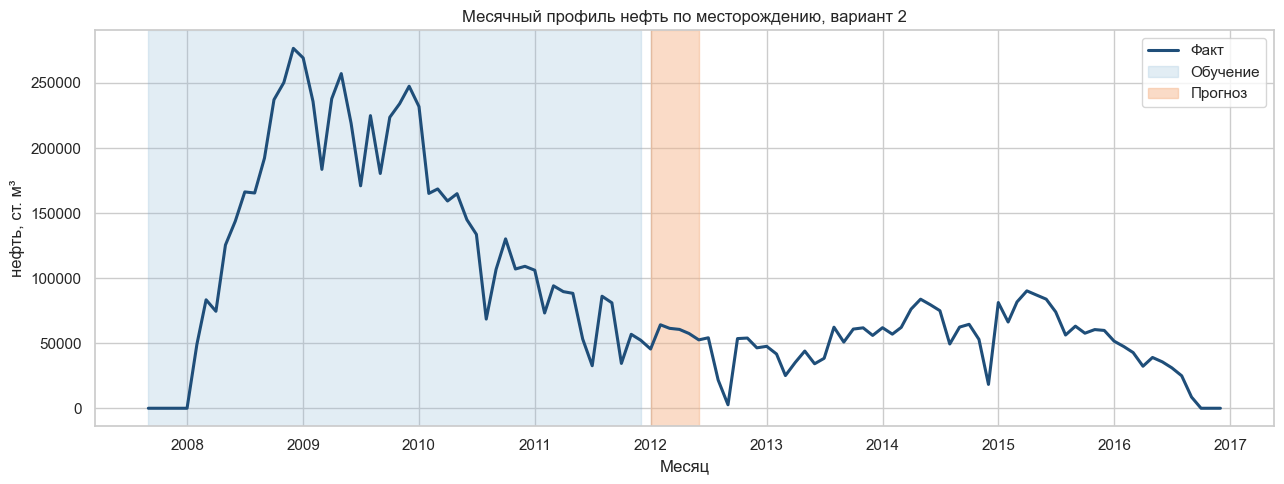

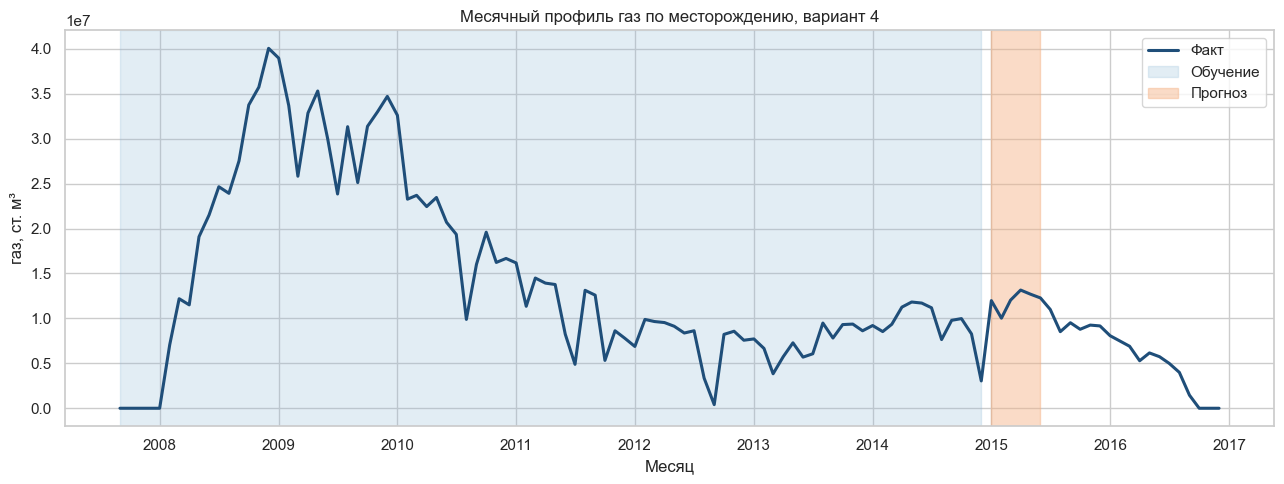

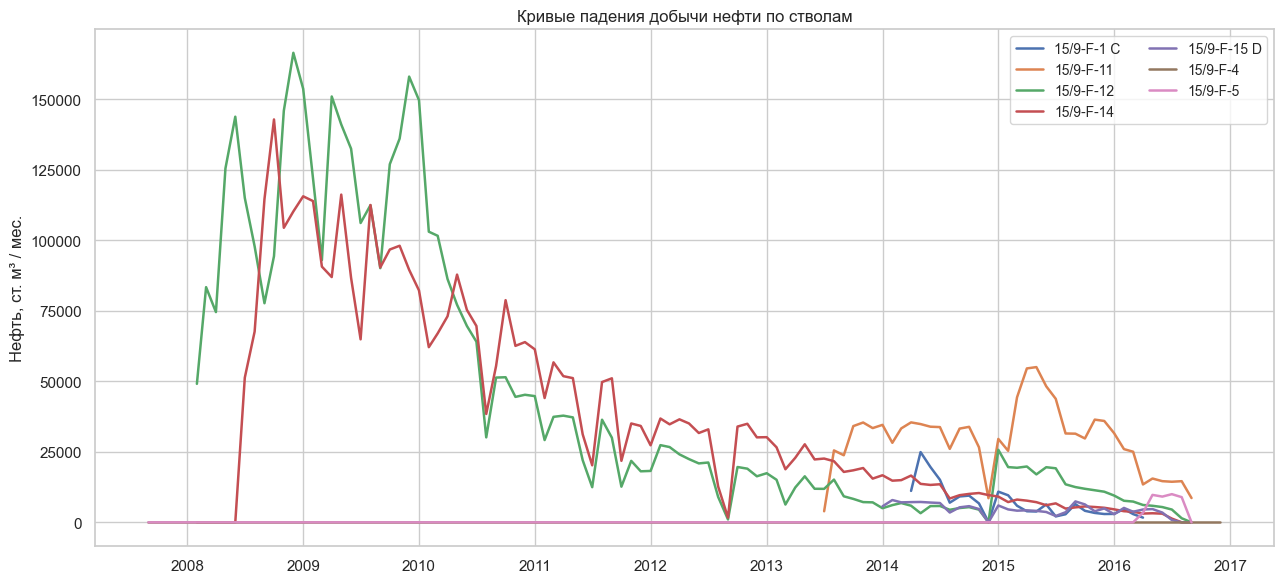

In [4]:
p = plot_field_history(field, WINDOWS, OIL_PROFILE_VARIANT, "oil", "profile_oil_window2.png")
print("график нефти, вариант 2:", p)
p = plot_field_history(field, WINDOWS, GAS_PROFILE_VARIANT, "gas", "profile_gas_window4.png")
print("график газа, вариант 4:", p)
p = plot_wells(monthly, "wells_oil_decline.png")
print("кривые скважин:", p)


## 3. Анализ временного ряда месторождения

Декомпозиция показывает тренд ввода скважин и последующее падение. Тест Дики-Фуллера проверяет стационарность: при нестационарности лаговая ML-модель опирается на разности косвенно, через лаги и линейный тренд `t`, а кривая Арпса явно описывает падение.


ADF статистика = -1.441, p-value = 0.5626
Ряд нефти нестационарен: есть тренд ввода мощностей и последующее падение.


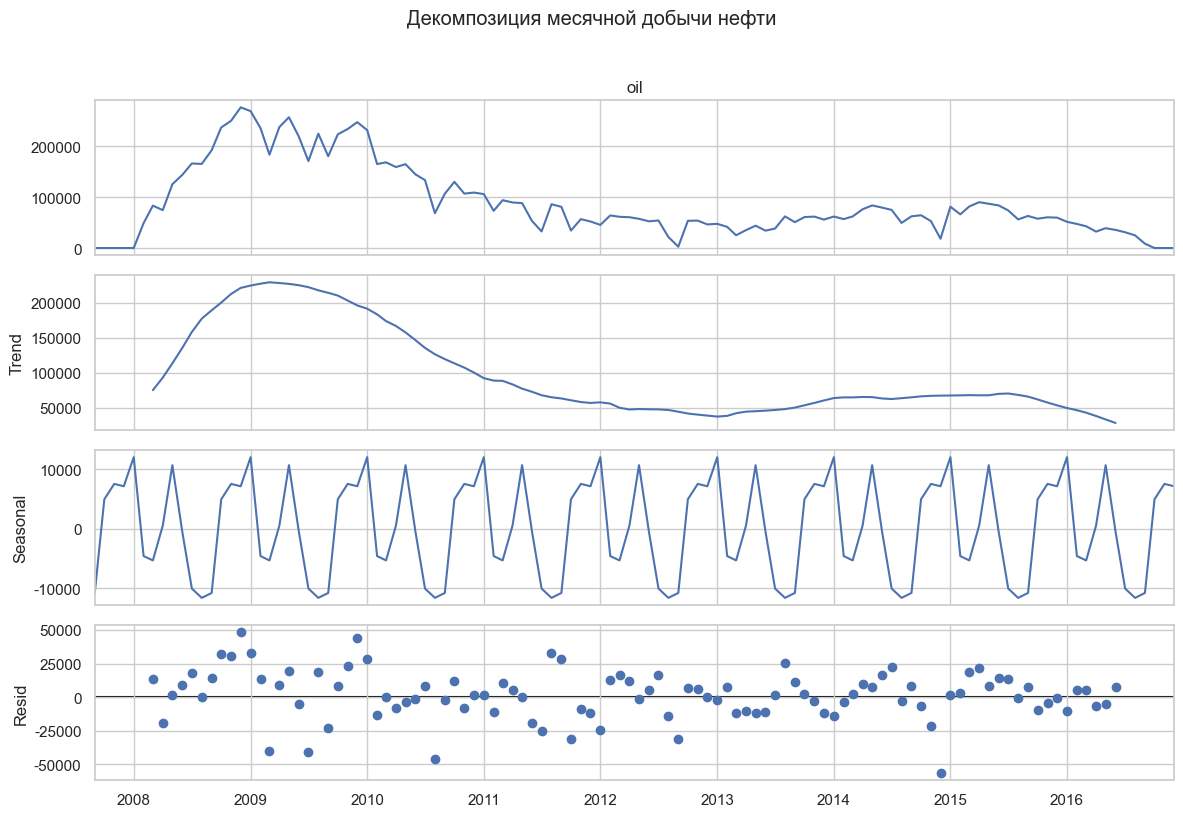

In [5]:
oil = field.set_index("DATE")["oil"].asfreq("MS").fillna(0)
decomp = seasonal_decompose(oil, model="additive", period=12)
plot_decomposition(decomp, "Декомпозиция месячной добычи нефти", "stl_oil.png")

adf_stat, adf_p, *_ = adfuller(oil.dropna())
print(f"ADF статистика = {adf_stat:.3f}, p-value = {adf_p:.4f}")
if adf_p < 0.05:
    print("Ряд нефти на полном периоде выглядит стационарным на уровне 5%.")
else:
    print("Ряд нефти нестационарен: есть тренд ввода мощностей и последующее падение.")


## 4. Подготовка признаков

Для каждой даты месторождения строим:

- календарь: номер месяца, sin/cos сезонности, порядковый индекс `t`;
- лаги добычи 1, 2, 3 и 6 месяцев;
- скользящее среднее за 3 и 6 месяцев;
- лаги воды, времени работы и числа добывающих стволов.

Разбиение только хронологическое. Рекурсивный прогноз на 6 шагов подставляет уже полученные значения обратно в лаги.


In [6]:
supervised = make_supervised(field, "oil").dropna()
print("строк для обучения на полном ряде:", len(supervised))
display(supervised[["DATE", "oil", "oil_lag1", "oil_lag3", "oil_lag6", "oil_rmean3", "month_sin"]].head(8))


строк для обучения на полном ряде: 103


,DATE,oil,oil_lag1,oil_lag3,oil_lag6,oil_rmean3,month_sin
6,2008-03-01,"83,361.26","49,091.06",0.00,0.00,"16,363.69",1.00
7,2008-04-01,"74,532.45","83,361.26",0.00,0.00,"44,150.77",0.87
8,2008-05-01,"125,478.56","74,532.45","49,091.06",0.00,"68,994.92",0.50
9,2008-06-01,"143,786.85","125,478.56","83,361.26",0.00,"94,457.42",0.00
10,2008-07-01,"166,279.69","143,786.85","74,532.45",0.00,"114,599.29",-0.50
11,2008-08-01,"165,443.66","166,279.69","125,478.56","49,091.06","145,181.70",-0.87
12,2008-09-01,"192,263.21","165,443.66","143,786.85","83,361.26","158,503.40",-1.00
13,2008-10-01,"237,174.29","192,263.21","166,279.69","74,532.45","174,662.19",-0.87


## 5. Модели

**Baseline — кривая Арпса.** Экспонента \( q(t) = q_i e^{-d_i t} \) и гипербола \( q(t) = q_i (1 + b d_i t)^{-1/b} \). Подгоняем на истории месторождения и отдельно по стволам, затем суммируем скважинные кривые.

**ML.** Ridge на стандартизованных лагах: устойчив на коротких окнах (в варианте 1 всего около двух лет добычи).

**Холт.** Линейный тренд без сезонности — запасной кандидат, если ряд достаточно длинный.

**Смесь.** Среднее устойчивых кандидатов. На каждом окне лучший кандидат выбирается по WAPE на последних 6 месяцах **обучения**, без подглядывания в контрольный прогноз.


выбранные семейства на окне 2: {'oil': 'ridge_lags', 'gas': 'ridge_lags', 'oil_val_wape': nan, 'gas_val_wape': nan}
прогноз нефти: [74668.5 73664.3 66550.9 64770.1 59740.3 57046.3]
прогноз газа: [10893340.6 10758519.7  9579395.6  9150817.6  8342658.3  7906957.8]


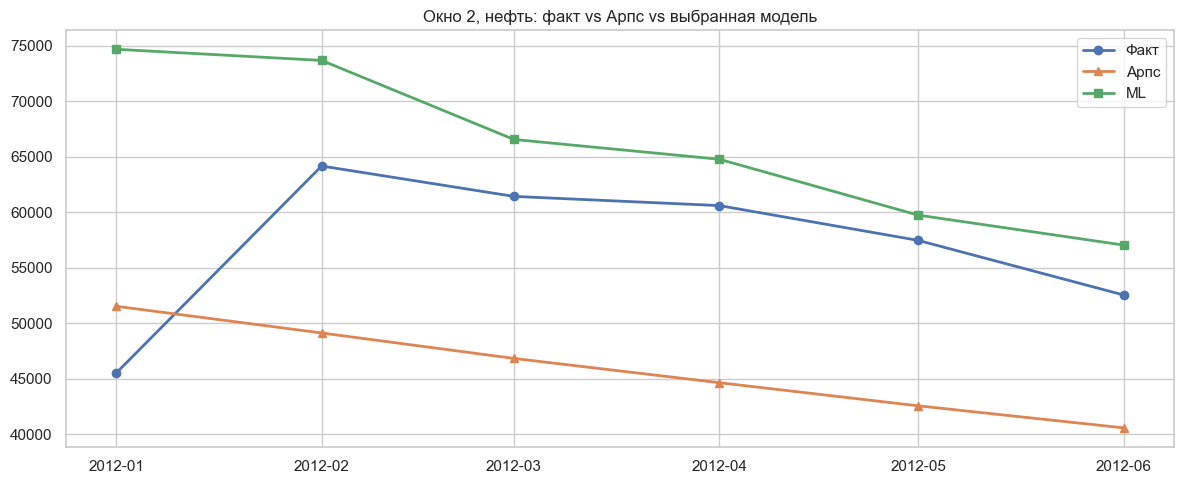

In [7]:
# Пример: окно 2, нефть — факт, Арпс и выбранная модель рядом
win = WINDOWS[1]
forecaster = FieldForecaster()
result = forecaster.fit_predict(field, monthly, win.train_end)
actual = field.loc[(field["DATE"] >= win.forecast_start) & (field["DATE"] <= win.forecast_end)]
arps_pred = forecast_arps(field.loc[field["DATE"] <= win.train_end, "oil"], 6)
plot_compare_arps_ml(
    actual.set_index("DATE")["oil"].reindex(result.dates).fillna(0),
    result.dates,
    arps_pred,
    result.oil,
    "Окно 2, нефть: факт vs Арпс vs выбранная модель",
    "window2_oil_arps_vs_ml.png",
)
print("выбранные семейства на окне 2:", forecaster.chosen_)
print("прогноз нефти:", np.round(result.oil, 1))
print("прогноз газа:", np.round(result.gas, 1))


## 6. Оценка на пяти контрольных окнах

Для каждого варианта и каждого флюида строим:

1. график факта и прогноза;
2. абсолютную ошибку по месяцам;
3. относительную ошибку по месяцам;
4. MAE, MAPE, WAPE (плюс RMSE и R² для сопоставления с классической постановкой задачи 2).

По всем окнам считаем

\[
\mathrm{RMS\,WAPE} = \sqrt{rac{1}{N}\sum_i \mathrm{WAPE}_i^2}.
\]


,variant,fluid,train_end,forecast_start,forecast_end,model,MAE,RMSE,R2,MAPE,WAPE
0,1,oil,2009-12-01,2010-01-01,2010-06-01,blend,"59,803.35","65,740.01",-4.65,37.56,34.68
1,1,gas,2009-12-01,2010-01-01,2010-06-01,blend,"7,947,014.50","8,663,617.74",-4.15,35.15,32.62
2,2,oil,2011-12-01,2012-01-01,2012-06-01,ridge_lags,"9,118.30","12,965.28",-3.28,17.76,16.01
3,2,gas,2011-12-01,2012-01-01,2012-06-01,ridge_lags,"1,099,995.60","1,725,491.74",-1.81,14.36,12.35
4,3,oil,2013-12-01,2014-01-01,2014-06-01,ridge_lags,"21,518.19","26,891.71",-6.03,28.00,30.70
5,3,gas,2013-12-01,2014-01-01,2014-06-01,ridge_lags,"3,053,100.22","3,824,980.75",-7.41,27.21,29.60
6,4,oil,2014-12-01,2015-01-01,2015-06-01,ridge_lags,"12,691.91","18,373.90",-4.88,15.61,15.53
7,4,gas,2014-12-01,2015-01-01,2015-06-01,ridge_lags,"1,722,034.70","2,556,280.72",-5.76,14.38,14.32
8,5,oil,2015-12-01,2016-01-01,2016-06-01,ridge_lags,"12,128.27","12,674.41",-2.67,30.79,29.25
9,5,gas,2015-12-01,2016-01-01,2016-06-01,ridge_lags,"1,460,132.64","1,545,873.07",-1.52,23.12,22.11


,fluid,RMS_WAPE,mean_WAPE
0,oil,26.45,25.23
1,gas,23.61,22.20


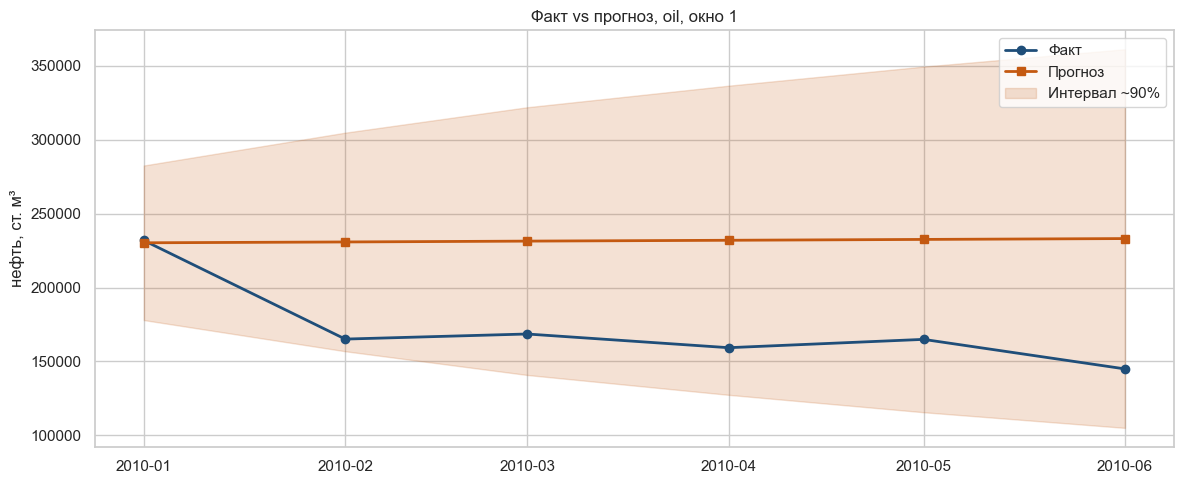

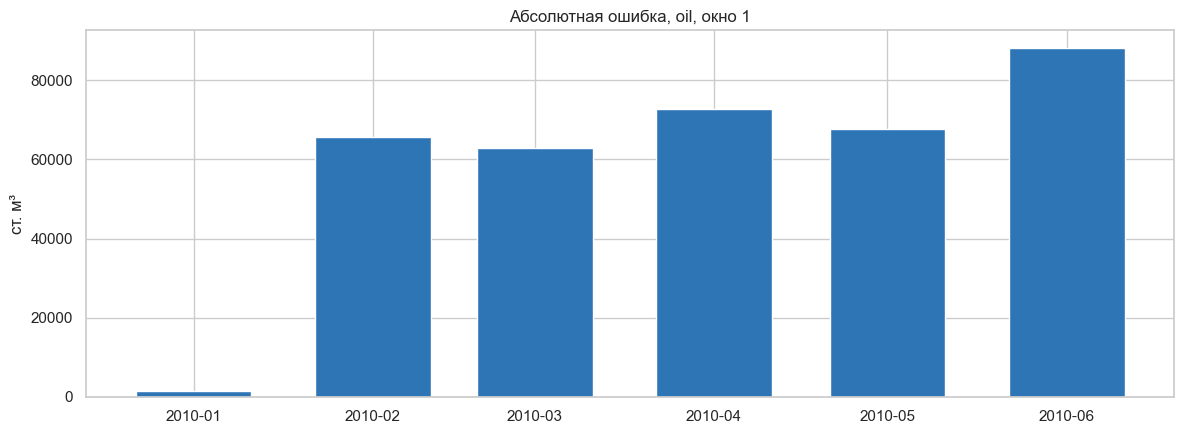

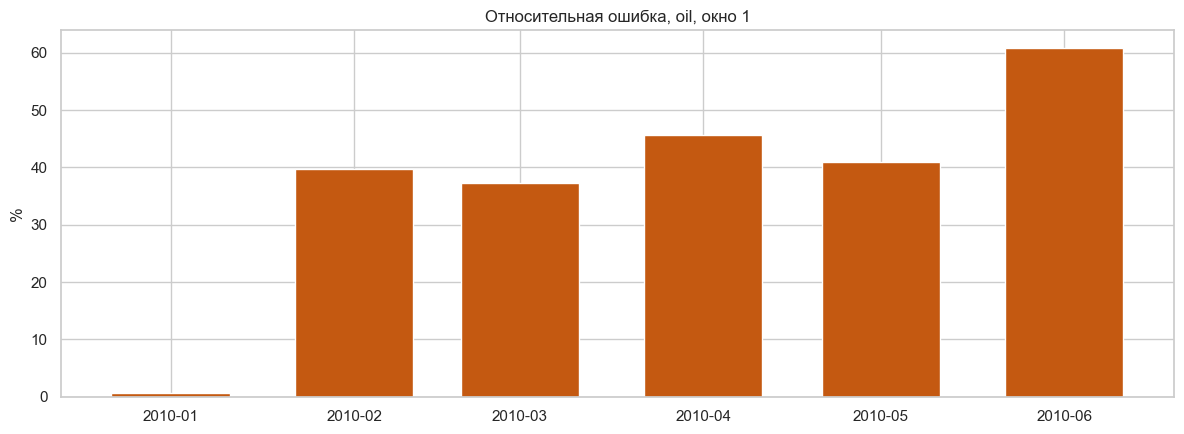

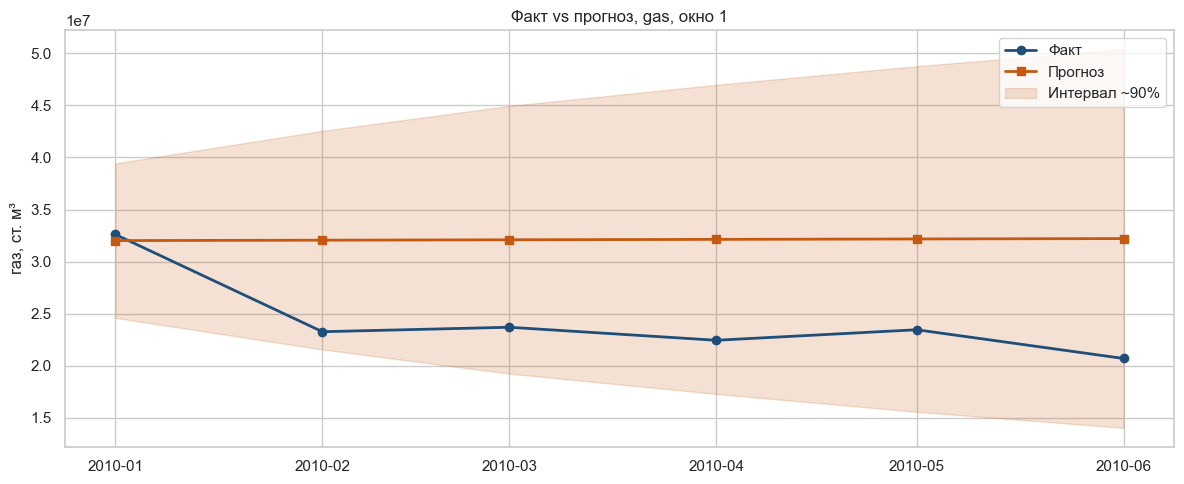

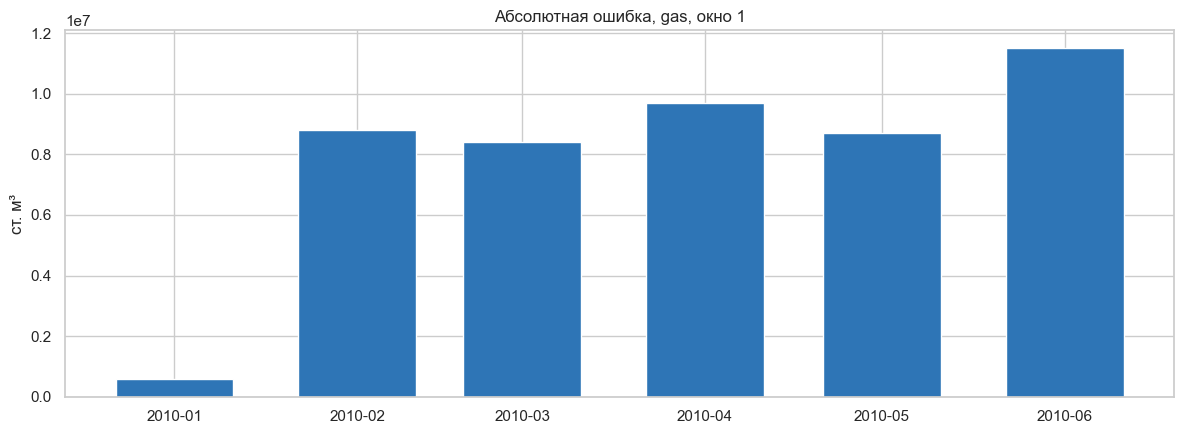

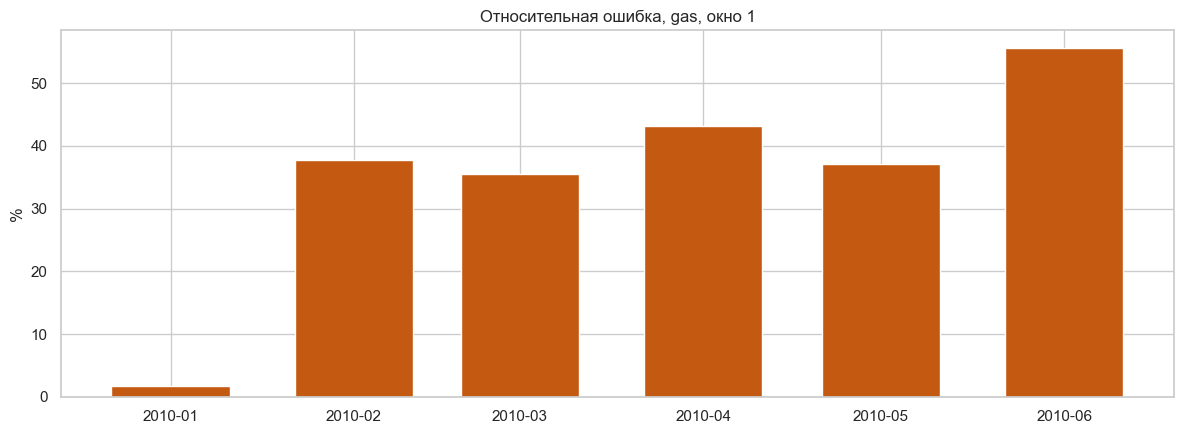

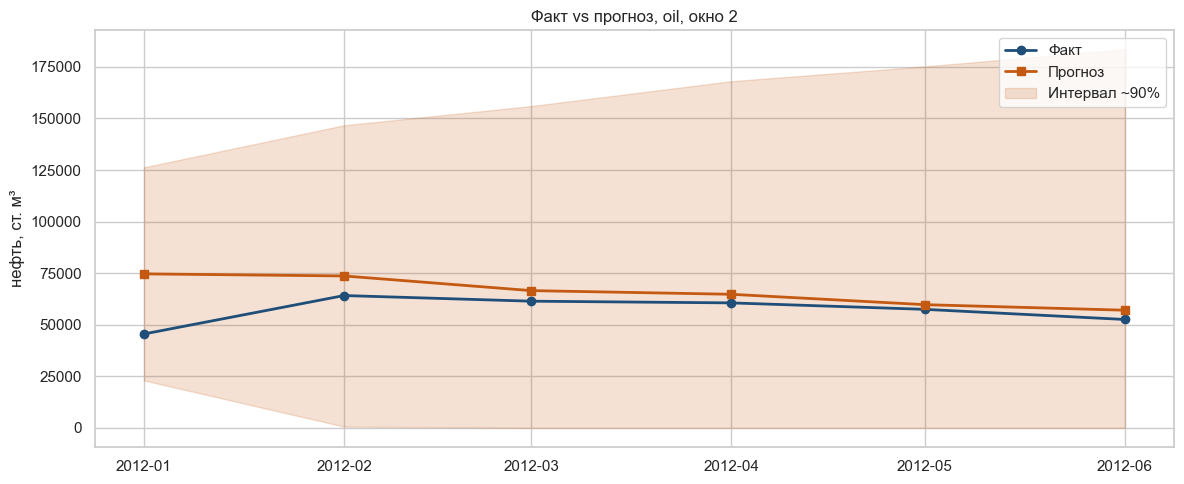

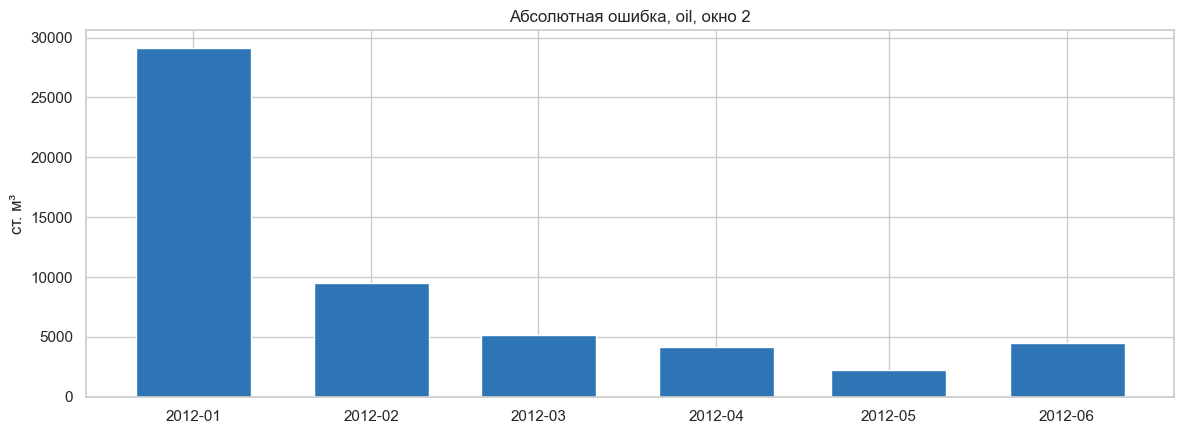

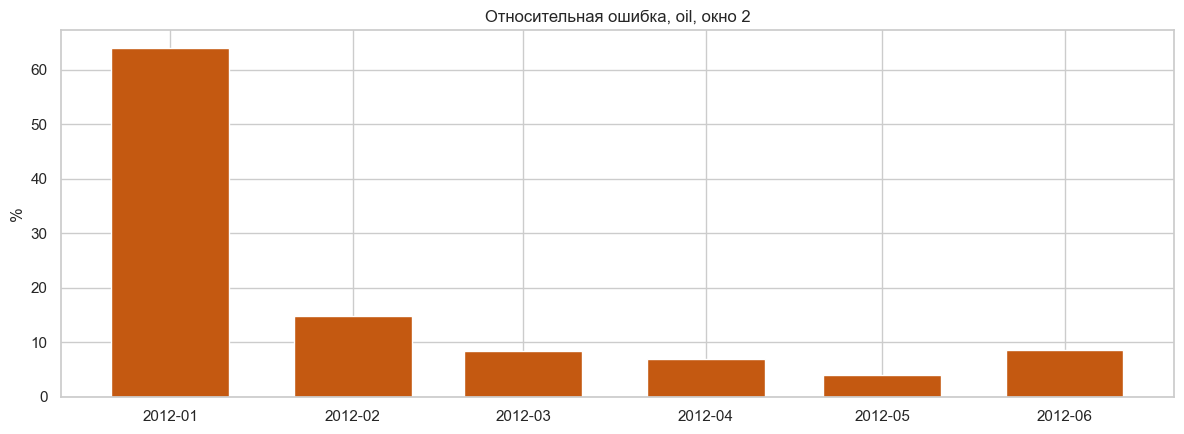

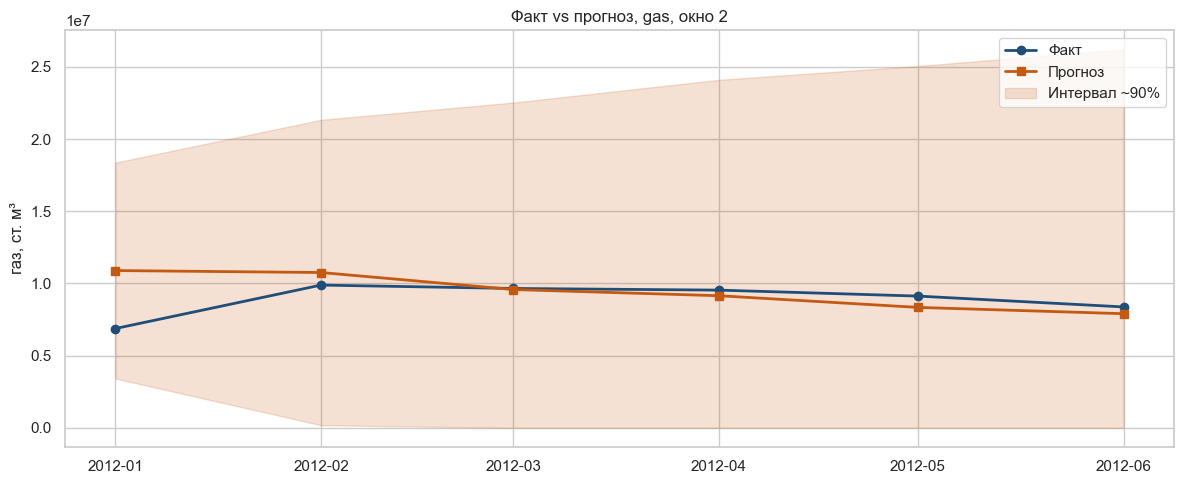

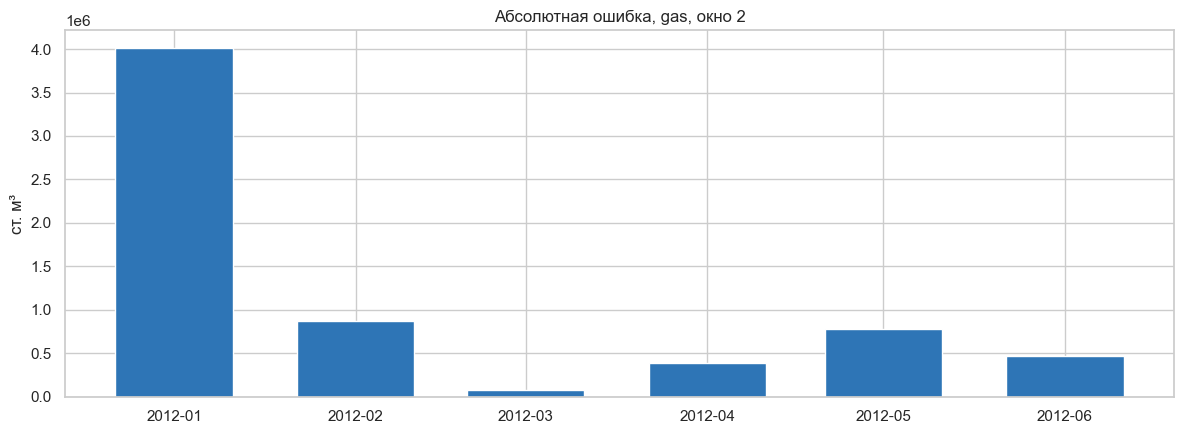

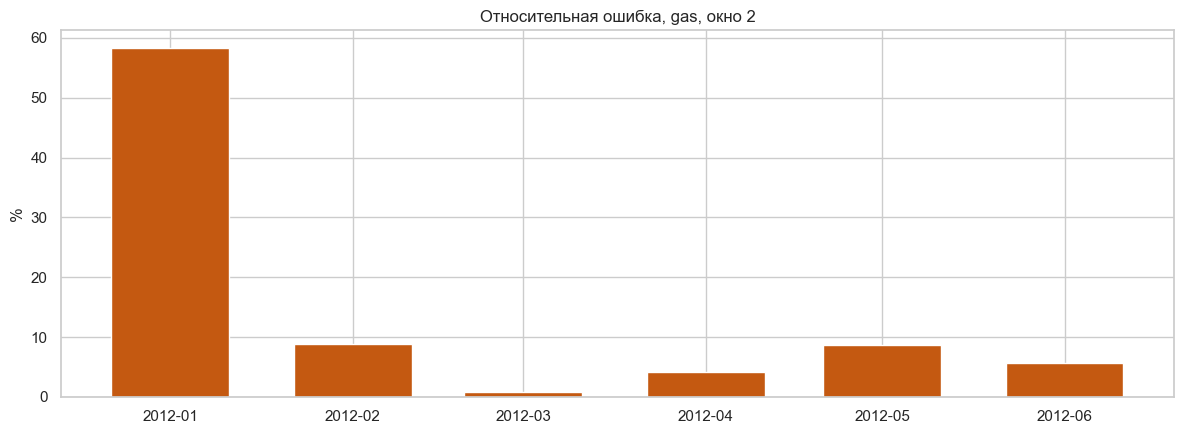

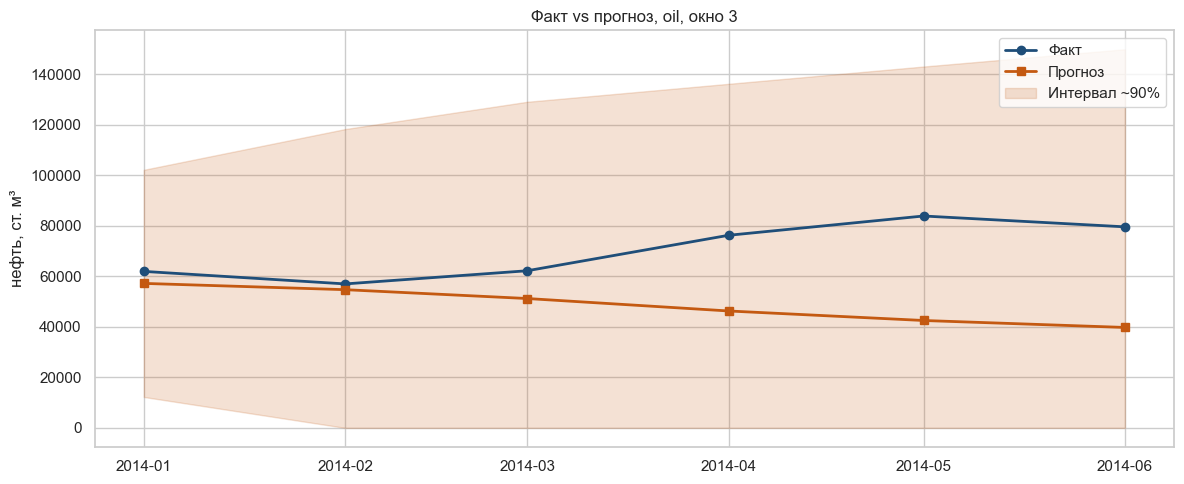

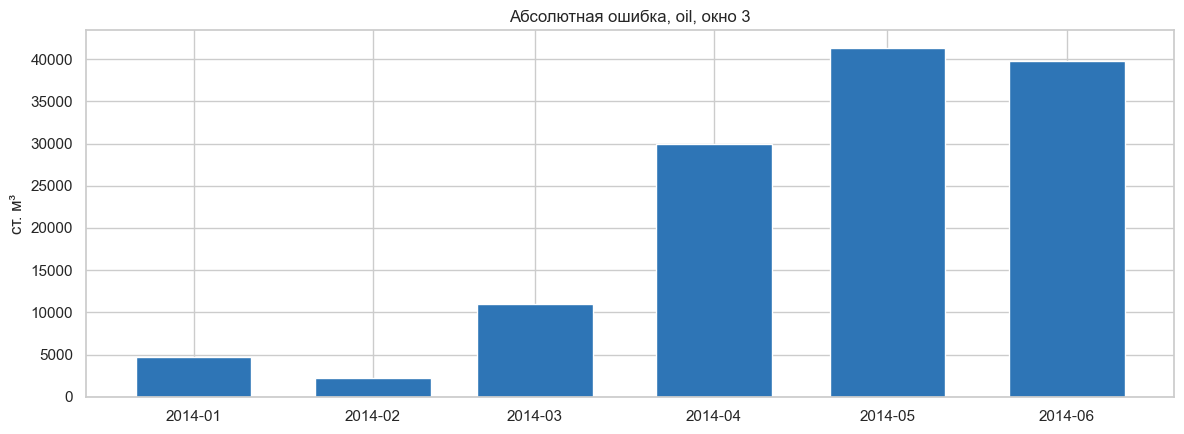

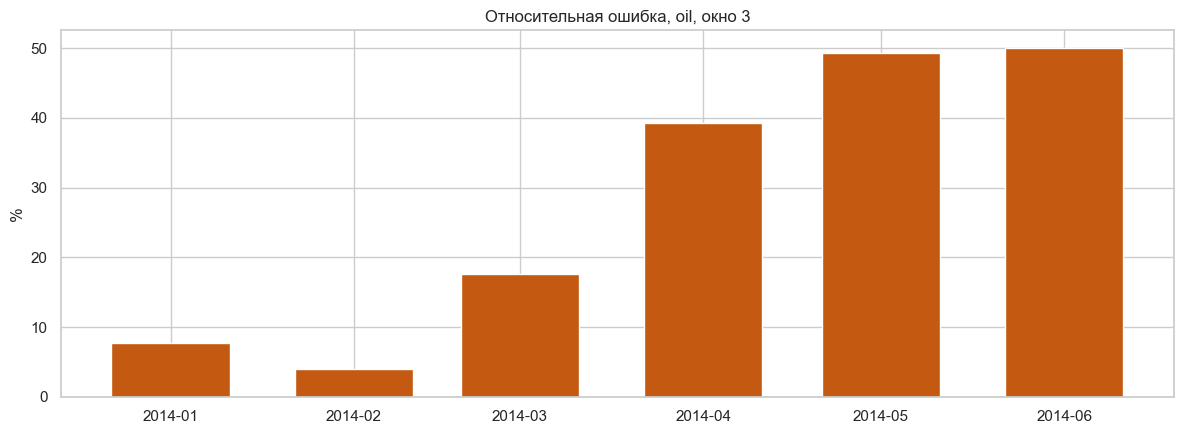

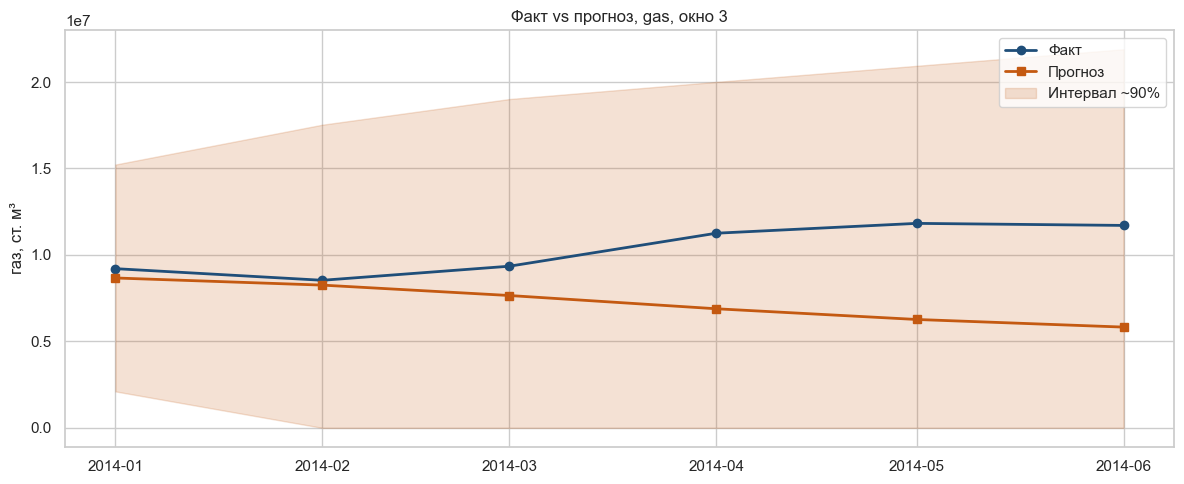

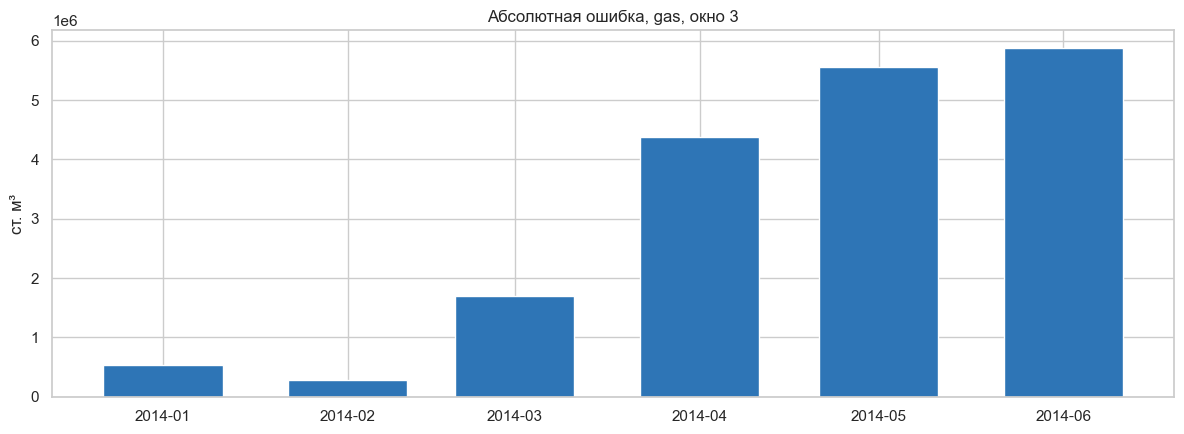

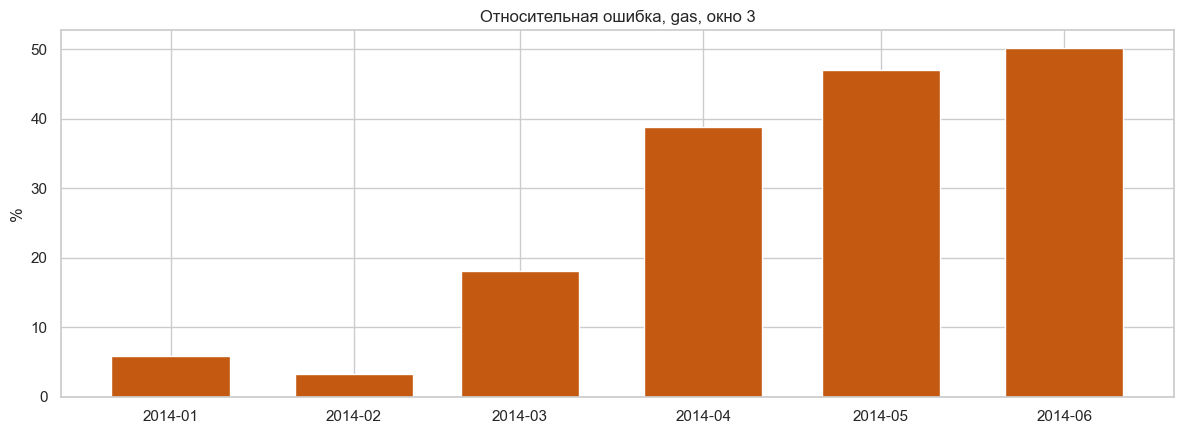

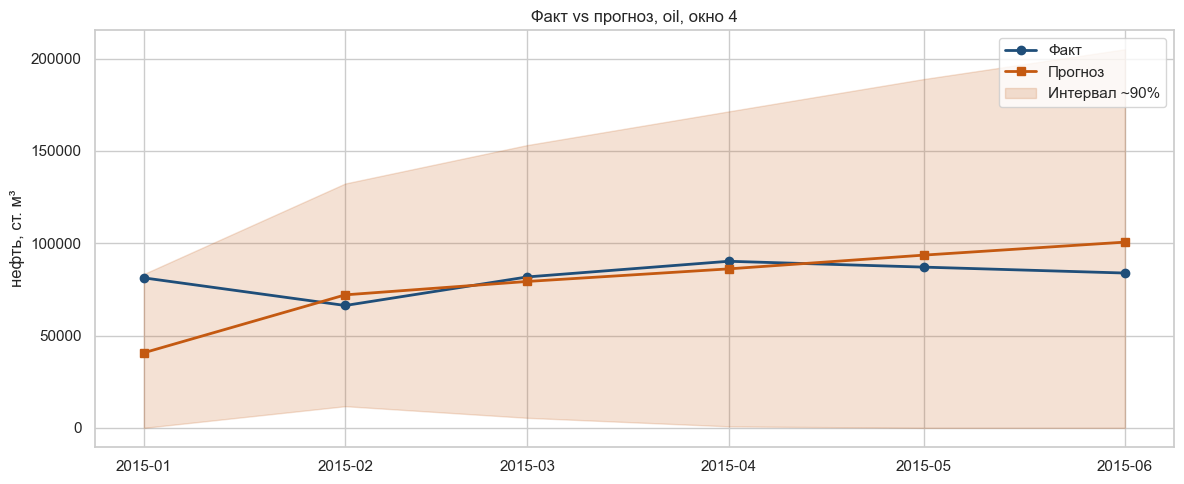

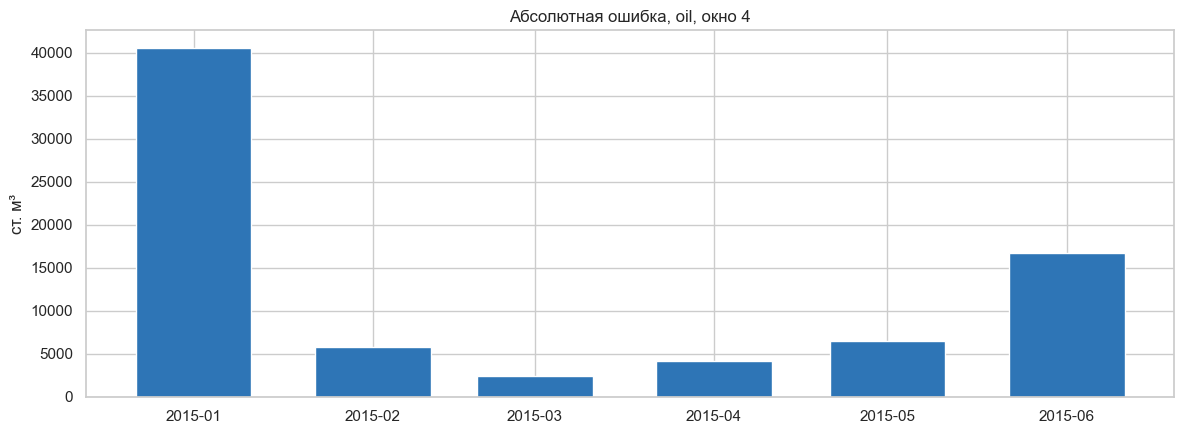

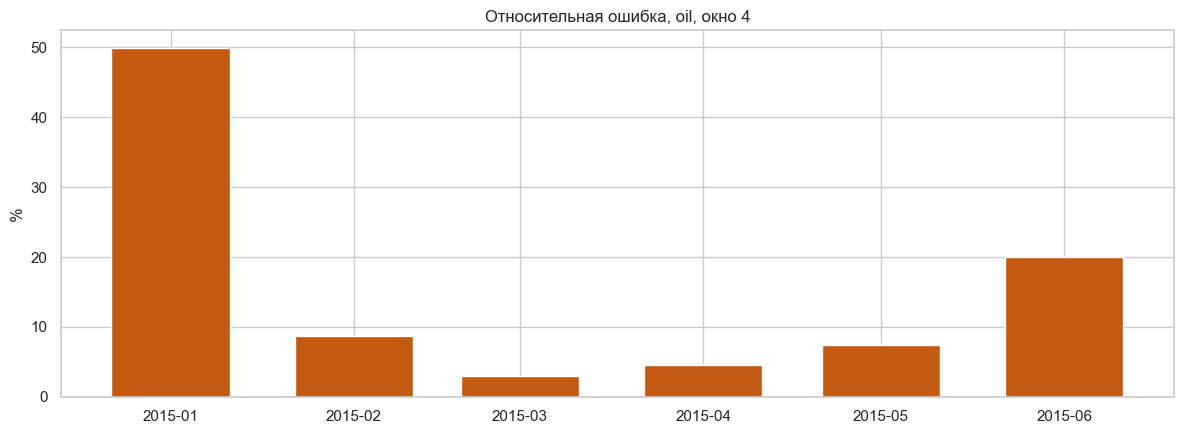

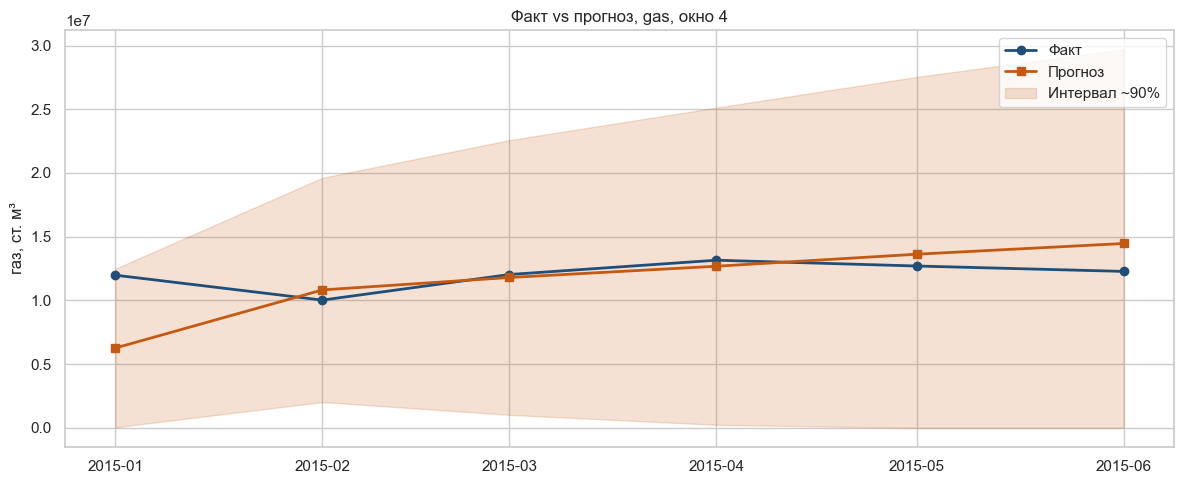

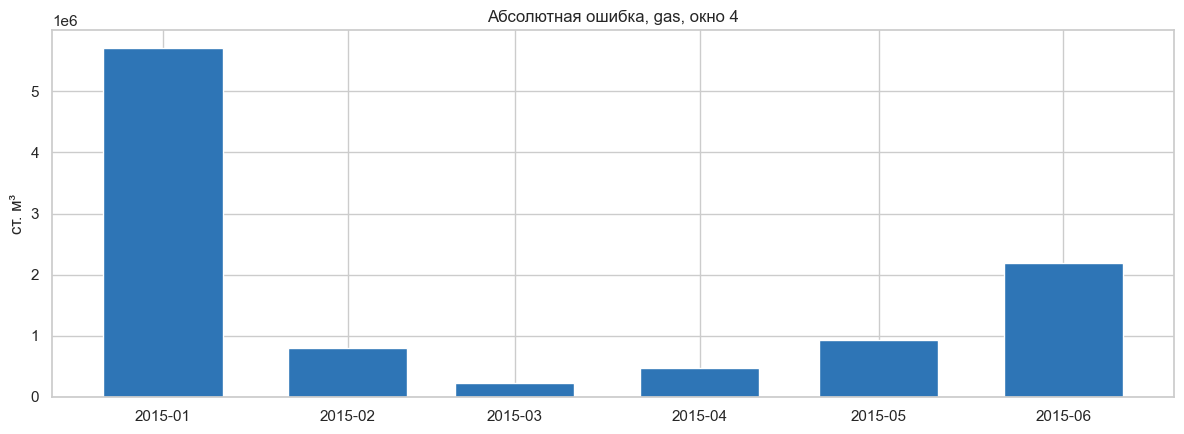

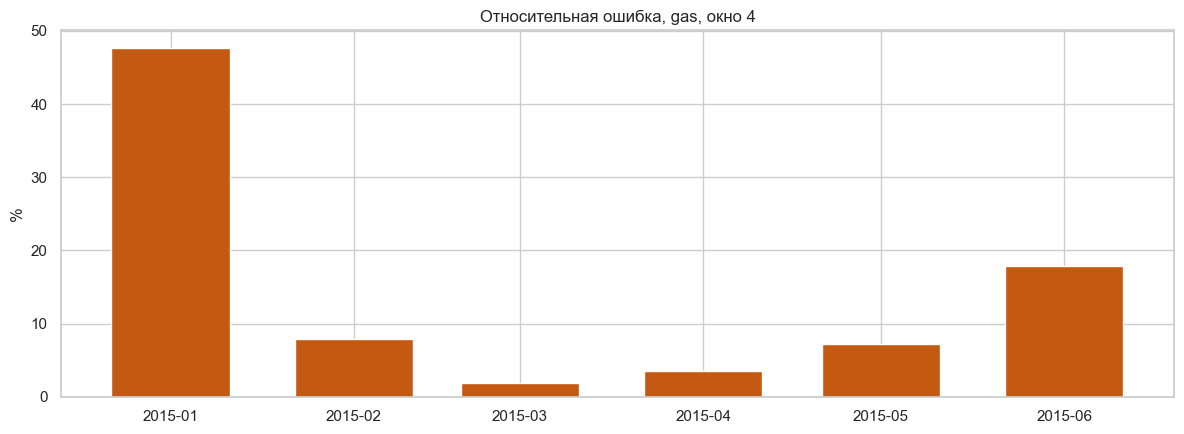

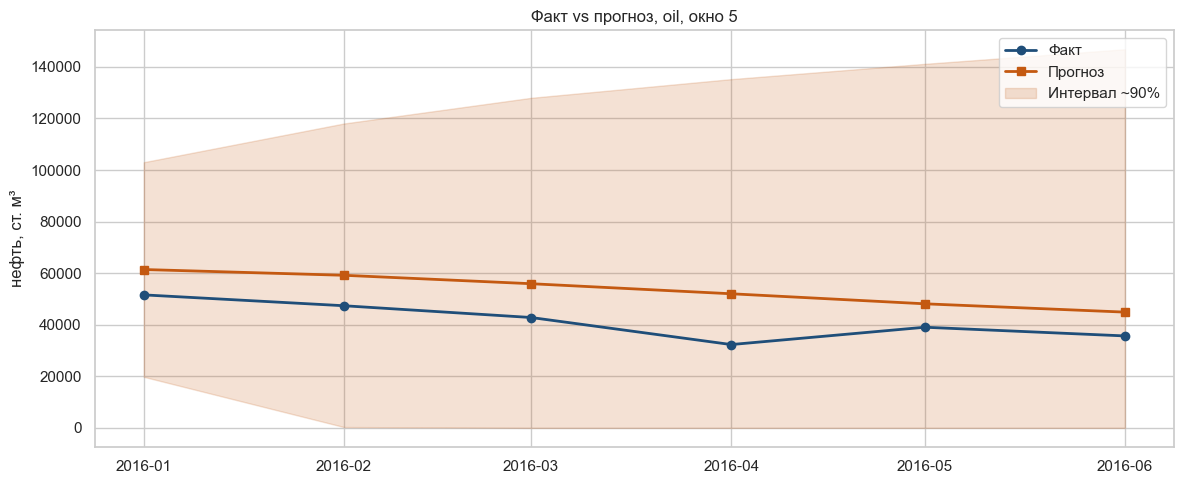

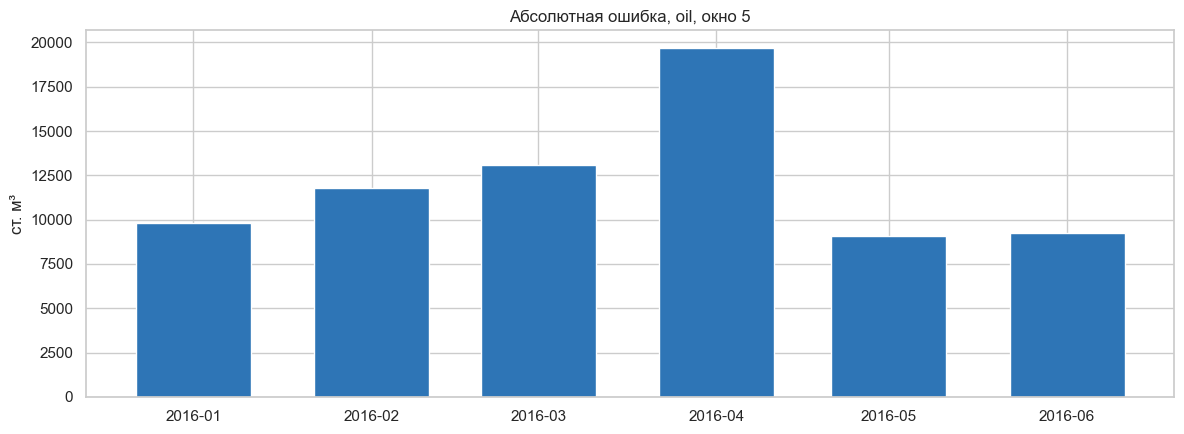

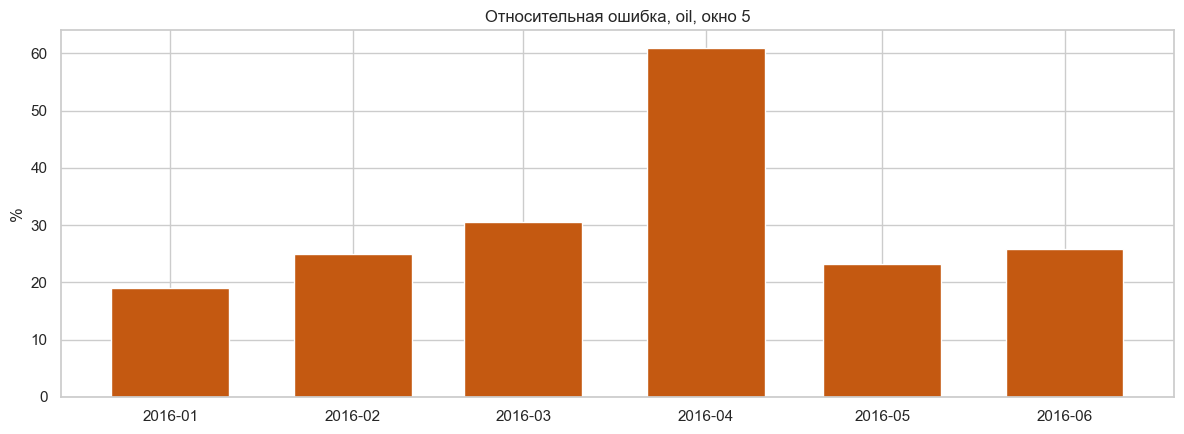

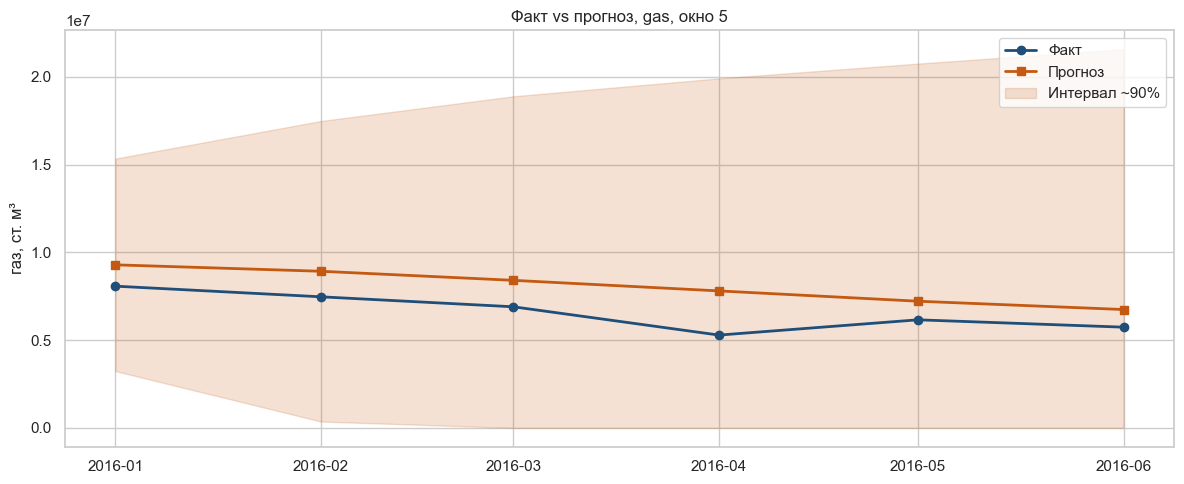

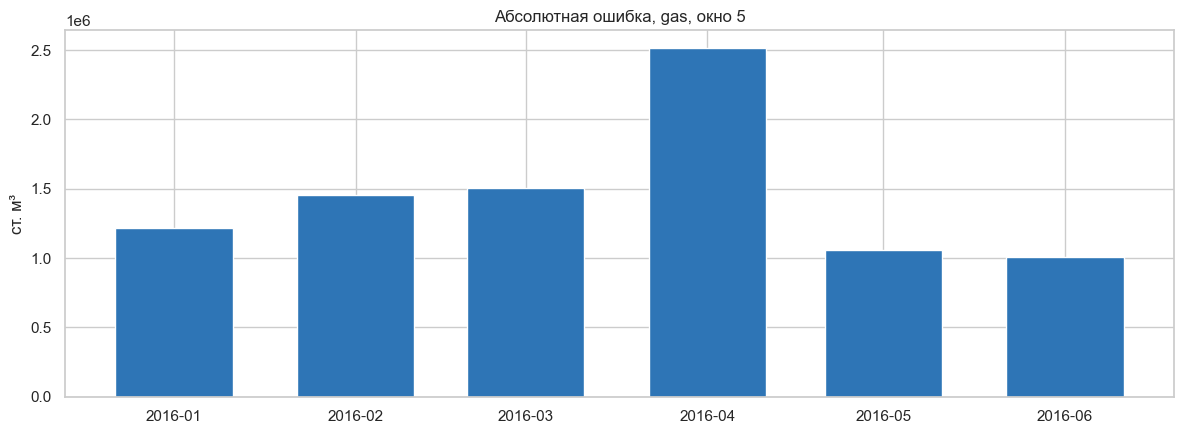

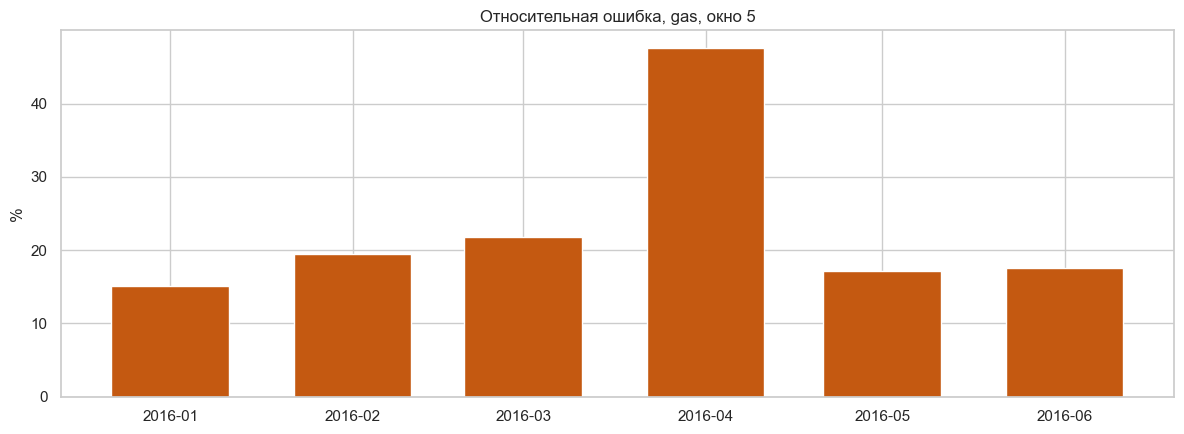

In [8]:
metrics, summary, details = evaluate_windows(field, monthly)
display(metrics)
display(summary)

for item in details:
    win = item["window"]
    result = item["result"]
    actual = item["actual"]
    for fluid in ("oil", "gas"):
        plot_forecast_vs_actual(actual, result, fluid, win.variant, f"w{win.variant}_{fluid}_fact_pred.png")
        pred = result.oil if fluid == "oil" else result.gas
        plot_errors(actual, pred, result.dates, fluid, win.variant, f"w{win.variant}_{fluid}")


In [9]:
# Сводная таблица в удобном виде и сохранение артефактов
pivot_wape = metrics.pivot(index="variant", columns="fluid", values="WAPE")
pivot_mae = metrics.pivot(index="variant", columns="fluid", values="MAE")
print("WAPE по окнам, %")
display(pivot_wape)
print("MAE по окнам, ст. м³")
display(pivot_mae)

metrics.to_csv("reports/metrics_windows.csv", index=False)
summary.to_csv("reports/metrics_summary.csv", index=False)
print("RMS WAPE нефть: {0:.2f}%".format(summary.loc[summary["fluid"] == "oil", "RMS_WAPE"].iloc[0]))
print("RMS WAPE газ:   {0:.2f}%".format(summary.loc[summary["fluid"] == "gas", "RMS_WAPE"].iloc[0]))


WAPE по окнам, %


fluid,gas,oil
variant,,
1,32.62,34.68
2,12.35,16.01
3,29.60,30.70
4,14.32,15.53
5,22.11,29.25


MAE по окнам, ст. м³


fluid,gas,oil
variant,,
1,"7,947,014.50","59,803.35"
2,"1,099,995.60","9,118.30"
3,"3,053,100.22","21,518.19"
4,"1,722,034.70","12,691.91"
5,"1,460,132.64","12,128.27"


RMS WAPE нефть: 26.45%
RMS WAPE газ:   23.61%


## 7. Скважинный взгляд (задача 2)

Для самой длинной добывающей скважины `15/9-F-12` повторяем логику на месячном ряде: хронологический тест, Арпс и Ridge. Это проверка, что модель не держится только на сумме месторождения и может работать по стволу.


скважина 15/9-F-12, окно как вариант 4
{'MAE': 11044.589297197233, 'RMSE': 12783.086607461708, 'R2': -22.141194078058188, 'MAPE': 52.21853003048692, 'WAPE': 54.783822193872666}


PosixPath('/Users/andreysorokin/Projects/volve-production-forecast/figures/well_f12_2015.png')

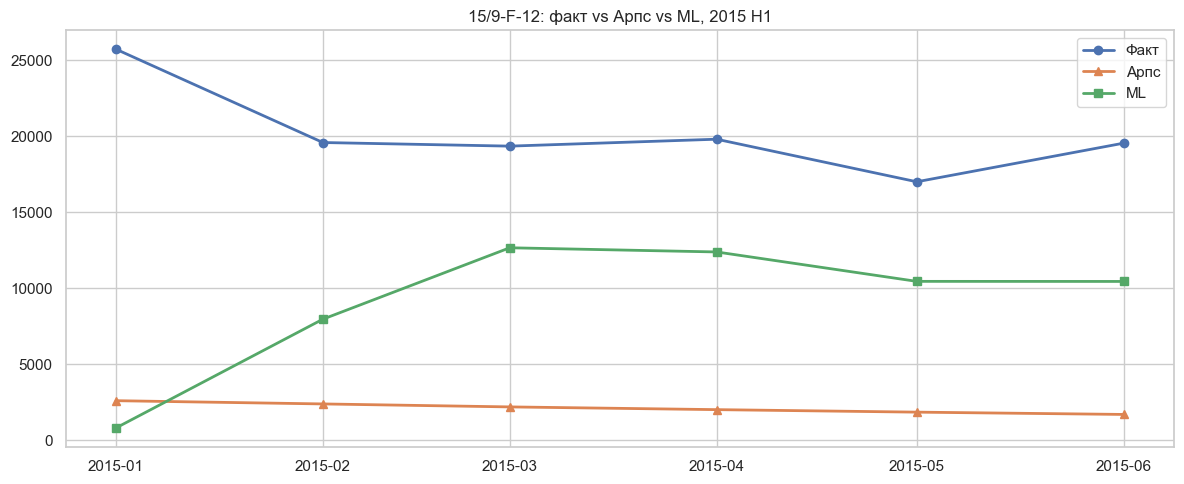

In [10]:
well = monthly.loc[monthly["WELL"] == "15/9-F-12", ["DATE", "OIL", "GAS", "WATER", "ON_STREAM_HRS"]].copy()
well = well.rename(columns={"OIL": "oil", "GAS": "gas", "WATER": "water", "ON_STREAM_HRS": "on_stream"})
well["n_producers"] = 1
well["n_wells"] = 1
well["gi"] = 0.0
well["wi"] = 0.0
well["gor"] = np.where(well["oil"] > 0, well["gas"] / well["oil"], np.nan)
well["water_cut"] = np.where(well["oil"] + well["water"] > 0, well["water"] / (well["oil"] + well["water"]), np.nan)

cutoff = pd.Timestamp("2014-12-01")
hist = well.loc[well["DATE"] <= cutoff]
future = well.loc[(well["DATE"] >= "2015-01-01") & (well["DATE"] <= "2015-06-01")]
fc = FieldForecaster()
# Для скважины используем тот же класс, подставив её ряд как «месторождение»
res = fc.fit_predict(well, monthly.loc[monthly["WELL"] == "15/9-F-12"].assign(OIL=lambda d: d["OIL"], GAS=lambda d: d["GAS"]), "2014-12-01")
y = future.set_index("DATE").reindex(res.dates)["oil"].fillna(0)
rep = regression_report(y, res.oil)
print("скважина 15/9-F-12, окно как вариант 4")
print(rep)
plot_compare_arps_ml(
    y,
    res.dates,
    forecast_arps(hist["oil"], 6),
    res.oil,
    "15/9-F-12: факт vs Арпс vs ML, 2015 H1",
    "well_f12_2015.png",
)


## 8. Как пользоваться моделью на практике

```python
from src.data import load_monthly, monthly_field
from src.models import FieldForecaster

monthly = load_monthly()
field = monthly_field(monthly)
model = FieldForecaster()
forecast = model.fit_predict(field, monthly, cutoff="2015-12-01")
forecast.oil, forecast.gas
```

Модель не требует будущих ГТМ, запусков новых скважин и режимов штуцера: она экстраполирует уже наблюдаемый профиль. Если известен план ввода скважин, его нужно подавать отдельно — иначе прогноз занизит добычу, как это происходит в окне 3.

## 9. Слабые стороны

- Нет признаков ГТМ, ремонтов и планового ввода стволов.
- Короткое первое окно: мало точек для сезонной модели.
- Рекурсия на 6 шагов накапливает ошибку лагов.
- MAPE неустойчив при почти нулевой добыче; поэтому основная метрика кейса — WAPE / RMS WAPE.
- Кривая Арпса плохо описывает рост после подключения новых скважин; ML и смесь это частично компенсируют, но чудес из пустой истории не делают.

## 10. Воспроизведение

```bash
python3 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
jupyter notebook solution.ipynb
```

Либо пакетный прогон:

```bash
python run_all.py
```
